# Tutorial: G25 Part A - Data Access, Confounds, EV Files, FEAT, and MRIcroGL

Audience:
- PSY 8310 classmates or new lab members who need one worked example from the `g25` project.

Prerequisites:
- A clone of the `g25` repository.
- JupyterLab or Jupyter Notebook.
- Internet access if the representative example files are not already cached.
- FSL available on `PATH`, or available through `ml fsl` / `module load fsl` in Neurodesk.
- MRIcroGL available on `PATH` for the visualization section.

Learning goals:
- Show the DataLad-style download workflow for the approved `ds007486` snapshot and keep the notebook runnable even when DataLad is unavailable locally.
- Build FEAT-ready confounds for one representative SST run without running full fMRIPrep.
- Convert BIDS `events.tsv` files to FSL 3-column EV files.
- Run one representative first-level FEAT model for `sub-11039` SST run 1.
- Visualize the resulting `zstat1` map in MRIcroGL and embed the captured image in the notebook.

Scope decision for this notebook:
- We are explicitly skipping full `fMRIPrep` execution here.
- For the confounds step, we use FSL motion estimates and framewise-displacement QC for a worked example on `sub-11039`.
- The first-level FEAT demo is a single-run worked example, because that is the smallest complete path from BIDS events to a statistical map.

How to run:
- Open this notebook from `g25/output/jupyter-notebook/`.
- Run the cells from top to bottom.
- Cached downloads are stored under `output/jupyter-notebook/_cache/`.
- FEAT demo artifacts are stored under `output/jupyter-notebook/feat-demo/`.
- Local EV files are written under `derivatives/fsl/EVfiles/`.


## Outline

1. Set up paths, helper functions, and a space-free runtime directory for FSL commands.
2. Show the DataLad download commands for `ds007486` and fall back to direct OpenNeuro downloads if DataLad is not installed on this machine.
3. Inspect one anatomy image and one SST BOLD run so we know the sample files are valid.
4. Build FEAT-ready confounds from FSL motion estimates and inspect the framewise-displacement QC output.
5. Convert the local SST `events.tsv` files to FSL 3-column EV files and inspect the resulting text files.
6. Generate or reuse one first-level FEAT run for `sub-11039` SST run 1 and inspect the design matrix.
7. Open the FEAT output in MRIcroGL, capture the MRIcroGL window back into a PNG, and display that image inline.
8. Summarize the key output files and likely troubleshooting points.


In [1]:
from __future__ import annotations

import importlib.util
import json
import os
import shutil
import ssl
import subprocess
import sys
import textwrap
import time
import urllib.request
from pathlib import Path

required = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'nibabel': 'nibabel',
}
missing = [pkg for mod, pkg in required.items() if importlib.util.find_spec(mod) is None]
if missing:
    raise RuntimeError(
        'This notebook expects the current Jupyter kernel to already provide: '
        + ', '.join(missing)
    )

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

plt.rcParams['figure.dpi'] = 120
CTX = ssl._create_unverified_context()
OPENNEURO_API = 'https://openneuro.org/crn/graphql'
DATASET_ID = 'ds007486'
SNAPSHOT_TAG = '1.0.0'
APPROVED_SUBJECTS = ['sub-10562', 'sub-10665', 'sub-11028', 'sub-11039', 'sub-11450']
SST_RUNS = [1, 2, 3]
SUBJECT = 'sub-11039'
TASK = 'SST'
RUN = 1
ECHO = 1
PROJECT_ROOT_OVERRIDE = os.environ.get('G25_PROJECT_ROOT', '').strip()
GIT_DATASET_URL = f'https://github.com/OpenNeuroDatasets/{DATASET_ID}.git'


def find_project_root(start: Path | None = None, override: str | Path | None = None) -> Path:
    candidates: list[Path] = []
    if override:
        candidates.append(Path(override).expanduser().resolve())

    start = Path.cwd() if start is None else Path(start)
    candidates.extend([start, *start.parents])

    for candidate in candidates:
        if (candidate / 'bids').exists() and (candidate / 'code').exists():
            return candidate
        sibling_g25 = candidate / 'g25'
        if (sibling_g25 / 'bids').exists() and (sibling_g25 / 'code').exists():
            return sibling_g25

    raise FileNotFoundError(
        'Could not locate the g25 project root. Open the notebook from inside the g25 repo, '
        'keep a sibling g25 checkout next to this notebook repo, or set G25_PROJECT_ROOT=/path/to/g25 before launching Jupyter.'
    )


def run(cmd, cwd: Path | None = None, env: dict | None = None, check: bool = True) -> subprocess.CompletedProcess:
    run_env = dict(os.environ)
    if env:
        run_env.update(env)
    if cwd is not None:
        run_env['PWD'] = str(cwd)
        run_env['OLDPWD'] = str(cwd)
    result = subprocess.run(
        cmd,
        cwd=str(cwd) if cwd else None,
        env=run_env,
        check=False,
        capture_output=True,
        text=True,
    )
    if check and result.returncode != 0:
        raise RuntimeError(
            f"Command failed ({result.returncode}): {cmd}\nSTDOUT\n{result.stdout}\nSTDERR\n{result.stderr}"
        )
    return result


def update_env_from_env0(env_dump: bytes) -> None:
    for entry in env_dump.split(b'\0'):
        if not entry or b'=' not in entry:
            continue
        key, value = entry.split(b'=', 1)
        os.environ[key.decode(errors='ignore')] = value.decode(errors='ignore')


def load_fsl_module_if_needed() -> tuple[bool, str | None]:
    required_tools = ['mcflirt', 'feat', 'fslnvols']
    if all(shutil.which(tool) for tool in required_tools):
        return True, 'already-on-path'

    attempts = [
        ('ml fsl', 'type ml >/dev/null 2>&1 && ml fsl'),
        ('module load fsl', 'type module >/dev/null 2>&1 && module load fsl'),
    ]
    for label, shell_cmd in attempts:
        result = subprocess.run(
            ['bash', '-lc', f"{shell_cmd} >/dev/null 2>&1 && env -0"],
            capture_output=True,
            check=False,
        )
        if result.returncode != 0 or not result.stdout:
            continue
        update_env_from_env0(result.stdout)
        if all(shutil.which(tool) for tool in required_tools):
            return True, label

    return False, None


def gql(query: str) -> dict:
    payload = json.dumps({'query': query}).encode('utf-8')
    req = urllib.request.Request(
        OPENNEURO_API,
        data=payload,
        headers={'Content-Type': 'application/json'},
        method='POST',
    )
    with urllib.request.urlopen(req, context=CTX) as resp:
        return json.load(resp)


def subject_directory_key(subject: str) -> str:
    query = f'''query {{
      snapshot(datasetId: "{DATASET_ID}", tag: "{SNAPSHOT_TAG}") {{
        files {{ filename directory key }}
      }}
    }}'''
    rows = gql(query)['data']['snapshot']['files']
    for row in rows:
        if row['directory'] and row['filename'] == subject:
            return row['key']
    raise FileNotFoundError(f'Missing subject directory for {subject}')


def child_directory_key(parent_key: str, dirname: str) -> str:
    query = f'''query {{
      snapshot(datasetId: "{DATASET_ID}", tag: "{SNAPSHOT_TAG}") {{
        files(tree: "{parent_key}") {{ filename directory key }}
      }}
    }}'''
    rows = gql(query)['data']['snapshot']['files']
    for row in rows:
        if row['directory'] and row['filename'] == dirname:
            return row['key']
    raise FileNotFoundError(f'Missing child directory {dirname}')


def file_rows(tree_key: str) -> list[dict]:
    query = f'''query {{
      snapshot(datasetId: "{DATASET_ID}", tag: "{SNAPSHOT_TAG}") {{
        files(tree: "{tree_key}") {{ filename key urls size }}
      }}
    }}'''
    return gql(query)['data']['snapshot']['files']


def file_url_map(tree_key: str) -> dict[str, str]:
    rows = file_rows(tree_key)
    return {row['filename']: row['urls'][0] for row in rows if row.get('urls')}


def download_remote_file(filename: str, url_map: dict[str, str], destination: Path) -> Path:
    destination.parent.mkdir(parents=True, exist_ok=True)
    needs_download = (not destination.exists()) or destination.stat().st_size == 0
    if needs_download:
        with urllib.request.urlopen(url_map[filename], context=CTX) as resp:
            destination.write_bytes(resp.read())
    if destination.stat().st_size == 0:
        raise RuntimeError(f'Downloaded empty file for {filename}')
    return destination


def plot_orthogonal_slices(volume: np.ndarray, title: str, out_path: Path, cmap: str = 'gray') -> None:
    volume = np.asarray(volume)
    x, y, z = [dim // 2 for dim in volume.shape[:3]]
    vmax = float(np.percentile(volume, 99))
    vmin = float(np.percentile(volume, 1))

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(np.rot90(volume[x, :, :]), cmap=cmap, vmin=vmin, vmax=vmax)
    axes[0].set_title('Sagittal')
    axes[1].imshow(np.rot90(volume[:, y, :]), cmap=cmap, vmin=vmin, vmax=vmax)
    axes[1].set_title('Coronal')
    axes[2].imshow(np.rot90(volume[:, :, z]), cmap=cmap, vmin=vmin, vmax=vmax)
    axes[2].set_title('Axial')
    for ax in axes:
        ax.axis('off')
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(out_path, bbox_inches='tight')
    plt.show()
    plt.close(fig)


def find_first_command(candidates: list[str]) -> str | None:
    for candidate in candidates:
        command = shutil.which(candidate)
        if command:
            return command
    return None


def render_with_mricrogl(script_source: str, out_path: Path) -> tuple[Path, str, str | None]:
    mricrogl_cmd = find_first_command(['mricrogl', 'MRIcroGL'])
    mricron_cmd = find_first_command(['mricron', 'MRIcron'])
    if mricrogl_cmd is None:
        raise FileNotFoundError(
            'Could not find mricrogl/MRIcroGL on PATH. '
            'This notebook is written for Neurodesk environments where MRIcroGL is available as a command-line tool.'
        )

    script_path = RUNTIME_ROOT / 'mricrogl_render.py'
    script_path.write_text(script_source)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    attempts = [
        [mricrogl_cmd, str(script_path)],
        [mricrogl_cmd, '-s', str(script_path)],
    ]
    last_error = None
    for cmd in attempts:
        result = run(cmd, cwd=RUNTIME_ROOT, check=False)
        if out_path.exists() and out_path.stat().st_size > 0:
            return out_path, mricrogl_cmd, mricron_cmd
        last_error = f'Tried {cmd}\nSTDOUT\n{result.stdout}\nSTDERR\n{result.stderr}'
    raise RuntimeError(f'MRIcroGL did not create {out_path}.\n{last_error}')


PROJECT_ROOT = find_project_root(override=PROJECT_ROOT_OVERRIDE)
BIDS_ROOT = PROJECT_ROOT / 'bids'
CODE_DIR = PROJECT_ROOT / 'code'
OUTPUT_DIR = PROJECT_ROOT / 'output' / 'jupyter-notebook'
CACHE_DIR = OUTPUT_DIR / '_cache'
FIG_DIR = OUTPUT_DIR / 'figures'
FEAT_DEMO_DIR = OUTPUT_DIR / 'feat-demo'
CONF_DIR = FEAT_DEMO_DIR / 'confounds'
FEAT_FIG_DIR = FEAT_DEMO_DIR / 'figures'

for path in [OUTPUT_DIR, CACHE_DIR, FIG_DIR, FEAT_DEMO_DIR, CONF_DIR, FEAT_FIG_DIR]:
    path.mkdir(parents=True, exist_ok=True)


def choose_runtime_paths(project_root: Path, output_dir: Path) -> tuple[Path, Path, str]:
    if ' ' not in str(project_root):
        runtime_root = output_dir / '_runtime'
        runtime_root.mkdir(parents=True, exist_ok=True)
        return runtime_root, project_root, 'project-local'

    runtime_root = Path('/tmp/g25_parta_runtime')
    runtime_root.mkdir(parents=True, exist_ok=True)
    runtime_project = runtime_root / project_root.name
    if runtime_project.exists() or runtime_project.is_symlink():
        if runtime_project.resolve() != project_root.resolve():
            runtime_project.unlink()
    if not runtime_project.exists():
        runtime_project.symlink_to(project_root, target_is_directory=True)
    return runtime_root, runtime_project, 'tmp-symlink'


RUNTIME_ROOT, RUNTIME_PROJECT, RUNTIME_MODE = choose_runtime_paths(PROJECT_ROOT, OUTPUT_DIR)

subject_key = subject_directory_key(SUBJECT)
anat_key = child_directory_key(subject_key, 'anat')
func_key = child_directory_key(subject_key, 'func')
ANAT_URLS = file_url_map(anat_key)
FUNC_URLS = file_url_map(func_key)

ANAT_FILENAME = f'{SUBJECT}_T1w.nii.gz'
BOLD_FILENAME = f'{SUBJECT}_task-{TASK}_run-{RUN}_echo-{ECHO}_part-mag_bold.nii.gz'
BOLD_JSON_FILENAME = f'{SUBJECT}_task-{TASK}_run-{RUN}_echo-{ECHO}_part-mag_bold.json'
EVENTS_FILENAME = f'{SUBJECT}_task-{TASK}_run-{RUN}_events.tsv'

EXAMPLE_CACHE = CACHE_DIR / 'download-visualize' / SUBJECT
EXAMPLE_CACHE.mkdir(parents=True, exist_ok=True)
ANAT_PATH = EXAMPLE_CACHE / ANAT_FILENAME
BOLD_PATH = EXAMPLE_CACHE / BOLD_FILENAME
BOLD_JSON_PATH = EXAMPLE_CACHE / BOLD_JSON_FILENAME
LOCAL_EVENTS_PATH = BIDS_ROOT / SUBJECT / 'func' / EVENTS_FILENAME

DATALAD_ROOT = CACHE_DIR / 'datalad' / DATASET_ID
DATALAD_SUBJECT_ROOT = DATALAD_ROOT / SUBJECT
FSL_READY, FSL_LOAD_METHOD = load_fsl_module_if_needed()
MGL_CMD = find_first_command(['mricrogl', 'MRIcroGL'])
MCRON_CMD = find_first_command(['mricron', 'MRIcron'])

print(f'Project root: {PROJECT_ROOT}')
print(f'Local BIDS root: {BIDS_ROOT}')
print(f'Notebook output dir: {OUTPUT_DIR}')
print(f'Runtime root: {RUNTIME_ROOT}')
print(f'Runtime mode: {RUNTIME_MODE}')
print(f'DataLad root: {DATALAD_ROOT}')
print(f'FSL available: {FSL_READY}')
print(f'FSL load method: {FSL_LOAD_METHOD}')
print(f'mcflirt command: {find_first_command(["mcflirt"])}')
print(f'feat command: {find_first_command(["feat"])}')
print(f'MRIcroGL command: {MGL_CMD}')
print(f'MRIcron command: {MCRON_CMD}')
print(f'Selected sample: {SUBJECT} {TASK} run-{RUN}')


Project root: /Users/kwakufinest/Documents/New project/group-3/g25
Local BIDS root: /Users/kwakufinest/Documents/New project/group-3/g25/bids
Notebook output dir: /Users/kwakufinest/Documents/New project/group-3/g25/output/jupyter-notebook
Runtime root: /tmp/g25_parta_runtime
Runtime mode: tmp-symlink
DataLad root: /Users/kwakufinest/Documents/New project/group-3/g25/output/jupyter-notebook/_cache/datalad/ds007486
FSL available: True
FSL load method: already-on-path
mcflirt command: /Users/kwakufinest/fsl/share/fsl/bin/mcflirt
feat command: /Users/kwakufinest/fsl/share/fsl/bin/feat
MRIcroGL command: None
MRIcron command: None
Selected sample: sub-11039 SST run-1


## Step 1 - Show the DataLad workflow and keep the notebook runnable

Purpose:
- The Neurodesk EDU guide uses DataLad for dataset access, so we first show the exact DataLad commands for `ds007486`.
- This notebook also needs to remain runnable on a local Mac that may not have `datalad` or `git-annex`, so the code falls back to direct OpenNeuro downloads when DataLad is unavailable.

What the code is doing:
- Check whether `datalad` and `git-annex` exist on this machine.
- Print the DataLad commands we would use in a fully configured environment.
- If DataLad is available, clone the dataset metadata and fetch only the representative files we need.
- If DataLad is unavailable, download the same representative files directly into the notebook cache so the rest of the tutorial can still run.

QC checkpoint:
- We should end this step with a valid T1w image, one SST BOLD run, its JSON sidecar, and the local SST `events.tsv` file.


In [2]:
datalad_cmd = shutil.which('datalad')
git_annex_cmd = shutil.which('git-annex')

datalad_plan = [
    f'datalad clone {GIT_DATASET_URL} {DATALAD_ROOT}',
    f'datalad get -d {DATALAD_ROOT} {DATALAD_SUBJECT_ROOT / "anat" / ANAT_FILENAME}',
    f'datalad get -d {DATALAD_ROOT} {DATALAD_SUBJECT_ROOT / "func" / BOLD_FILENAME}',
    f'datalad get -d {DATALAD_ROOT} {DATALAD_SUBJECT_ROOT / "func" / BOLD_JSON_FILENAME}',
]
display(pd.DataFrame({'planned_datalad_commands': datalad_plan}))

if datalad_cmd and git_annex_cmd:
    if not DATALAD_ROOT.exists():
        print('Cloning dataset metadata with DataLad...')
        print(run([datalad_cmd, 'clone', GIT_DATASET_URL, str(DATALAD_ROOT)]).stdout)

    for relative_path in [
        Path(SUBJECT) / 'anat' / ANAT_FILENAME,
        Path(SUBJECT) / 'func' / BOLD_FILENAME,
        Path(SUBJECT) / 'func' / BOLD_JSON_FILENAME,
    ]:
        target = DATALAD_ROOT / relative_path
        if not target.exists() or target.stat().st_size == 0:
            print(f'Fetching {relative_path} with DataLad...')
            print(run([datalad_cmd, 'get', '-d', str(DATALAD_ROOT), str(target)]).stdout)

    anat_path = DATALAD_ROOT / SUBJECT / 'anat' / ANAT_FILENAME
    bold_path = DATALAD_ROOT / SUBJECT / 'func' / BOLD_FILENAME
    bold_json_path = DATALAD_ROOT / SUBJECT / 'func' / BOLD_JSON_FILENAME
    download_mode = 'datalad'
else:
    anat_path = download_remote_file(ANAT_FILENAME, ANAT_URLS, ANAT_PATH)
    bold_path = download_remote_file(BOLD_FILENAME, FUNC_URLS, BOLD_PATH)
    bold_json_path = download_remote_file(BOLD_JSON_FILENAME, FUNC_URLS, BOLD_JSON_PATH)
    download_mode = 'direct-openneuro-fallback'

bold_meta = json.loads(bold_json_path.read_text())

summary = pd.DataFrame([
    {'mode_used': download_mode, 'tool_available': bool(datalad_cmd), 'file': anat_path.name, 'local_path': str(anat_path), 'size_mb': round(anat_path.stat().st_size / (1024 ** 2), 2)},
    {'mode_used': download_mode, 'tool_available': bool(datalad_cmd), 'file': bold_path.name, 'local_path': str(bold_path), 'size_mb': round(bold_path.stat().st_size / (1024 ** 2), 2)},
    {'mode_used': download_mode, 'tool_available': bool(datalad_cmd), 'file': bold_json_path.name, 'local_path': str(bold_json_path), 'size_mb': round(bold_json_path.stat().st_size / 1024, 2)},
    {'mode_used': 'local-bids', 'tool_available': True, 'file': LOCAL_EVENTS_PATH.name, 'local_path': str(LOCAL_EVENTS_PATH), 'size_mb': round(LOCAL_EVENTS_PATH.stat().st_size / 1024, 2)},
])

display(summary)
print(f'datalad found: {datalad_cmd}')
print(f'git-annex found: {git_annex_cmd}')
print(f"RepetitionTime from JSON: {bold_meta.get('RepetitionTime')}")

assert anat_path.exists()
assert bold_path.exists()
assert bold_json_path.exists()
assert LOCAL_EVENTS_PATH.exists()
assert float(bold_meta['RepetitionTime']) > 0


,planned_datalad_commands
0,datalad clone https://github.com/OpenNeuroData...
1,datalad get -d /Users/kwakufinest/Documents/Ne...
2,datalad get -d /Users/kwakufinest/Documents/Ne...
3,datalad get -d /Users/kwakufinest/Documents/Ne...


,mode_used,tool_available,file,local_path,size_mb
0,direct-openneuro-fallback,True,sub-11039_T1w.nii.gz,/Users/kwakufinest/Documents/New project/group...,7.95
1,direct-openneuro-fallback,True,sub-11039_task-SST_run-1_echo-1_part-mag_bold....,/Users/kwakufinest/Documents/New project/group...,150.31
2,direct-openneuro-fallback,True,sub-11039_task-SST_run-1_echo-1_part-mag_bold....,/Users/kwakufinest/Documents/New project/group...,3.91
3,local-bids,True,sub-11039_task-SST_run-1_events.tsv,/Users/kwakufinest/Documents/New project/group...,8.14


datalad found: /Users/anaconda3/bin/datalad
git-annex found: None
RepetitionTime from JSON: 1.615


## Step 2 - Inspect the representative anatomy and BOLD files

Purpose:
- Before we build confounds or a FEAT model, we confirm that the downloaded files open correctly and have the dimensions we expect.

What the code is doing:
- Load the representative T1w and SST BOLD files with `nibabel`.
- Print their shapes.
- Save one anatomy figure and one middle-volume BOLD figure into the notebook output folder.

QC checkpoint:
- The T1w image should be 3D.
- The BOLD file should be 4D.
- The saved PNG figures should display inline below the cell.


T1w shape: (192, 224, 224)
BOLD shape: (80, 80, 51, 305)
Middle volume index: 152


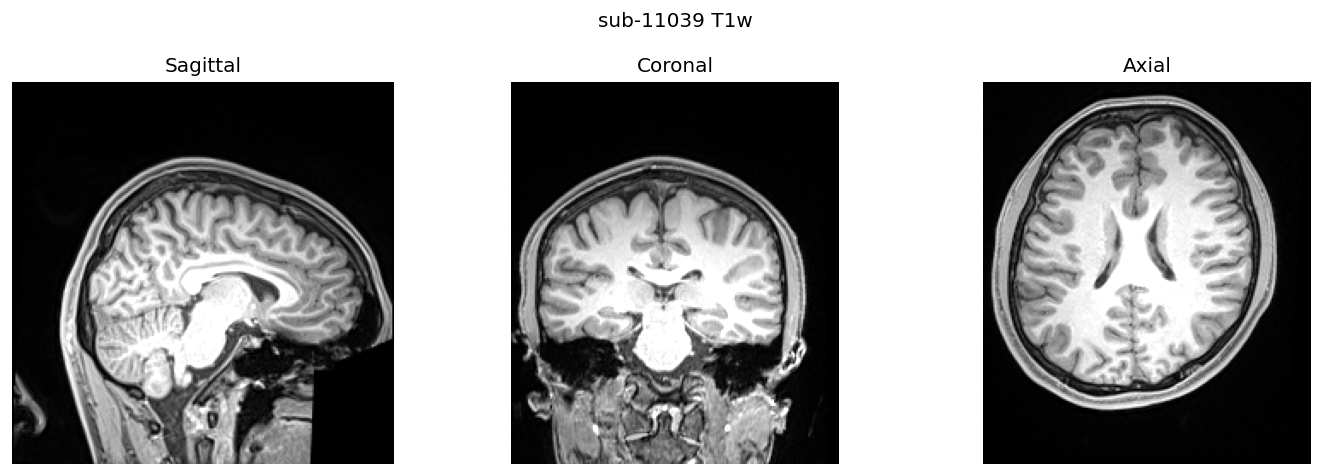

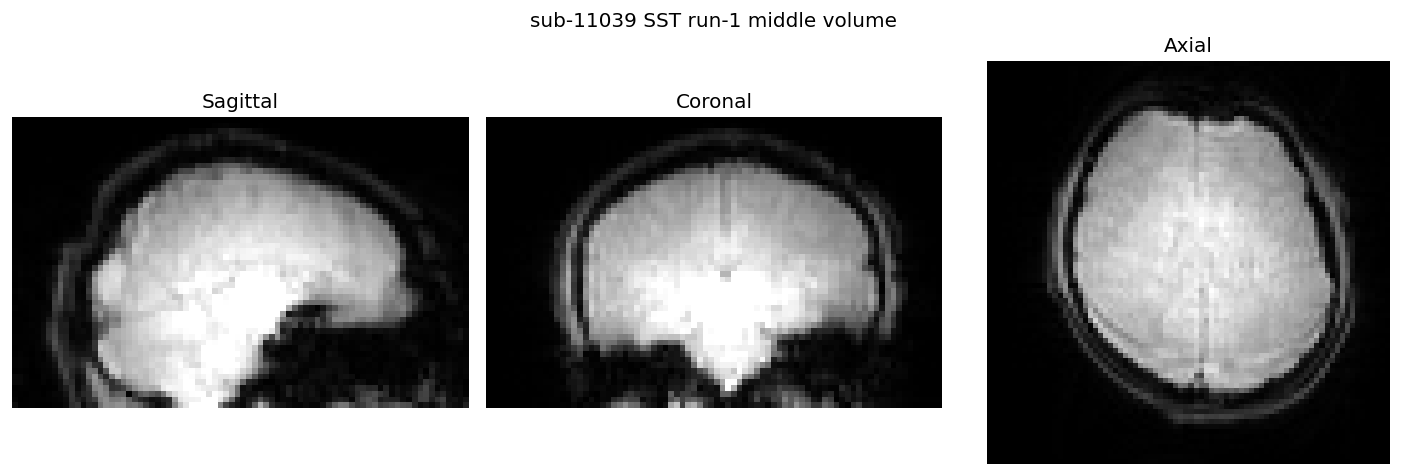

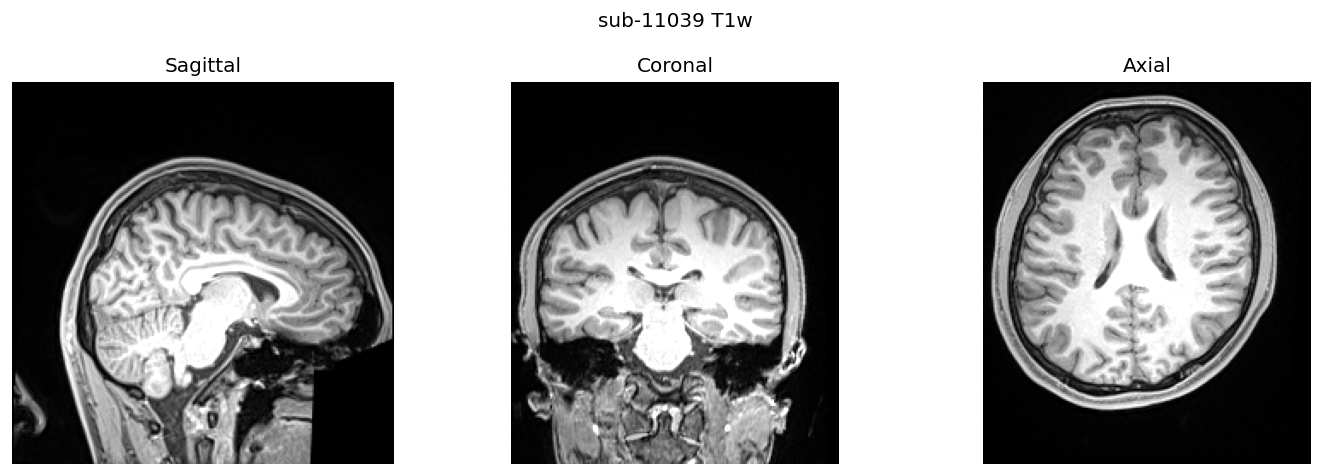

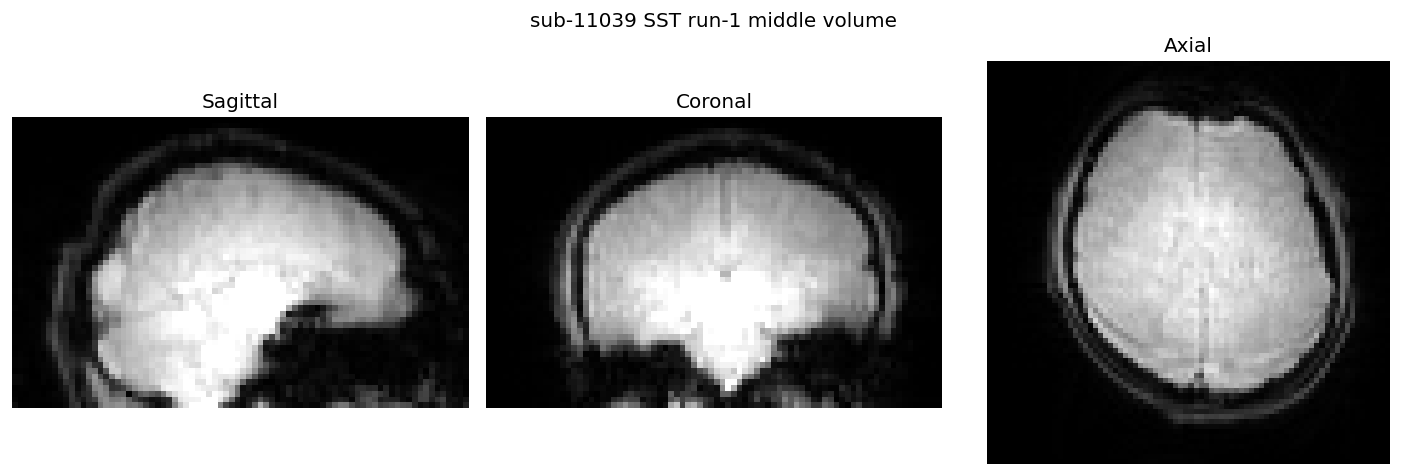

In [3]:
t1_img = nib.load(str(anat_path))
bold_img = nib.load(str(bold_path))
middle_bold_idx = bold_img.shape[3] // 2
middle_bold = np.asarray(bold_img.dataobj[..., middle_bold_idx])

t1_png = FIG_DIR / f'{SUBJECT}_T1w.png'
bold_png = FIG_DIR / f'{SUBJECT}_task-{TASK}_run-{RUN}_middle-volume.png'

print(f'T1w shape: {t1_img.shape}')
print(f'BOLD shape: {bold_img.shape}')
print(f'Middle volume index: {middle_bold_idx}')

assert len(t1_img.shape) == 3
assert len(bold_img.shape) == 4

plot_orthogonal_slices(np.asarray(t1_img.dataobj), f'{SUBJECT} T1w', t1_png)
plot_orthogonal_slices(middle_bold, f'{SUBJECT} {TASK} run-{RUN} middle volume', bold_png)

display(Image(filename=str(t1_png)))
display(Image(filename=str(bold_png)))


## Step 3 - Build FEAT-ready confounds without running fMRIPrep

Purpose:
- We are skipping full `fMRIPrep` in this notebook, so this section builds a practical FEAT-ready confound file from FSL motion estimates.

What the code is doing:
- Choose a runtime path that works in both environments: a project-local runtime in Neurodesk, or a `/tmp` symlink fallback when the local project path contains spaces.
- In Neurodesk, try `ml fsl` first and fall back to `module load fsl` if the FSL tools are not already on `PATH`.
- Run `mcflirt` to estimate the six rigid-body motion parameters and create a motion-corrected BOLD file.
- Compute framewise displacement directly from the `mcflirt` parameter file in Python so this notebook does not depend on `fsl_motion_outliers` being installed.
- Save the six-column motion parameters as the confound matrix used later in FEAT.
- Save the FD metric text file and FD QC plot into the notebook output folder so they persist after the session ends.

QC checkpoint:
- The FD metric text file and FD PNG plot should exist.
- The MCFLIRT `.par` file should have one row per BOLD volume and six columns.
- The notebook should display both a confound preview table and the FD plot inline.


Runtime BOLD used by FSL: /tmp/g25_parta_runtime/g25/output/jupyter-notebook/_cache/download-visualize/sub-11039/sub-11039_task-SST_run-1_echo-1_part-mag_bold.nii.gz
MCFLIRT corrected image: /tmp/g25_parta_runtime/feat-demo/mcflirt/sub-11039_task-SST_run-1_mcf.nii.gz
Confound rows/columns: (305, 6)
FD mean: 0.1607
FD max: 0.5365
Confounds TSV: /Users/kwakufinest/Documents/New project/group-3/g25/output/jupyter-notebook/feat-demo/confounds/sub-11039_task-SST_run-1_mcflirt_confounds.tsv
FD metric file: /Users/kwakufinest/Documents/New project/group-3/g25/output/jupyter-notebook/feat-demo/confounds/sub-11039_task-SST_run-1_fd-metric.txt
FD plot: /Users/kwakufinest/Documents/New project/group-3/g25/output/jupyter-notebook/feat-demo/confounds/sub-11039_task-SST_run-1_fd-plot.png


,rot_x,rot_y,rot_z,trans_x,trans_y,trans_z
0,-0.000780,-0.000767,0.001723,0.028362,-0.420035,-1.152740
1,-0.002084,-0.000407,0.001783,0.028524,-0.424093,-1.090850
2,-0.003564,0.001113,0.001975,0.049772,-0.347711,-0.811589
3,-0.003023,0.000870,0.001723,0.021556,-0.366703,-0.847925
4,-0.002310,0.000500,0.001659,0.028616,-0.288666,-0.726464


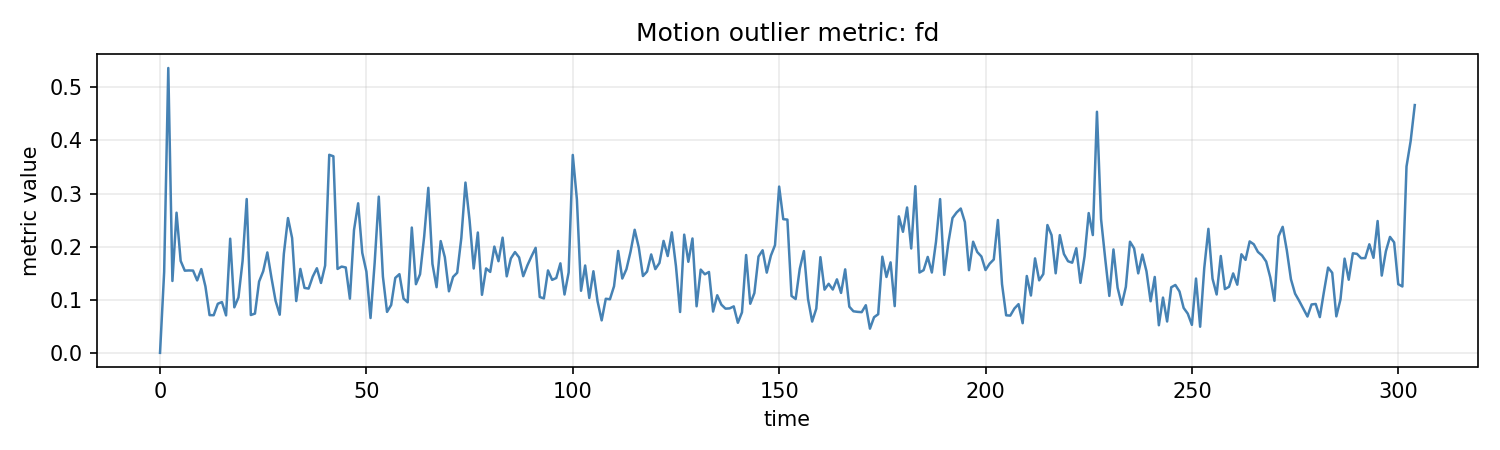

In [4]:
runtime_input_dir = RUNTIME_PROJECT / 'output' / 'jupyter-notebook' / '_cache' / 'download-visualize' / SUBJECT
runtime_feat_dir = RUNTIME_ROOT / 'feat-demo'
runtime_mc_dir = runtime_feat_dir / 'mcflirt'
runtime_mc_dir.mkdir(parents=True, exist_ok=True)
CONF_DIR.mkdir(parents=True, exist_ok=True)

runtime_bold = runtime_input_dir / BOLD_FILENAME
fd_metric_path = CONF_DIR / f'{SUBJECT}_task-{TASK}_run-{RUN}_fd-metric.txt'
fd_plot_path = CONF_DIR / f'{SUBJECT}_task-{TASK}_run-{RUN}_fd-plot.png'
mcflirt_base = runtime_mc_dir / f'{SUBJECT}_task-{TASK}_run-{RUN}_mcf'
mcflirt_par = mcflirt_base.with_suffix('.par')
fsl_ready, fsl_load_method = load_fsl_module_if_needed()
mcflirt_cmd = find_first_command(['mcflirt'])
if fsl_load_method and fsl_load_method != 'already-on-path':
    print(f'FSL load method for this cell: {fsl_load_method}')

if mcflirt_cmd is None:
    raise FileNotFoundError(
        'Could not find mcflirt on PATH, and automatic `ml fsl` / `module load fsl` did not succeed. '
        'Launch the notebook from a Neurodesk environment with FSL available.'
    )

if not mcflirt_par.exists() or not mcflirt_base.with_suffix('.nii.gz').exists():
    run([
        mcflirt_cmd,
        '-in', str(runtime_bold),
        '-out', str(mcflirt_base),
        '-plots',
        '-mats',
        '-report',
    ])

confound_columns = ['rot_x', 'rot_y', 'rot_z', 'trans_x', 'trans_y', 'trans_z']
confounds = pd.read_csv(mcflirt_par, sep=r'\s+', header=None, names=confound_columns)
confounds_path = CONF_DIR / f'{SUBJECT}_task-{TASK}_run-{RUN}_mcflirt_confounds.tsv'
confounds.to_csv(confounds_path, sep='	', index=False)

if not fd_metric_path.exists() or not fd_plot_path.exists():
    motion_values = confounds.to_numpy(dtype=float)
    fd_values = np.zeros(motion_values.shape[0], dtype=float)
    if motion_values.shape[0] > 1:
        diffs = np.abs(np.diff(motion_values, axis=0))
        fd_values[1:] = (50.0 * diffs[:, :3].sum(axis=1)) + diffs[:, 3:].sum(axis=1)

    fd_metric = pd.DataFrame({'framewise_displacement': fd_values})
    fd_metric.to_csv(fd_metric_path, header=False, index=False)

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(fd_metric.index, fd_metric['framewise_displacement'], linewidth=1.2, color='steelblue')
    ax.set_title('Motion outlier metric: fd')
    ax.set_xlabel('time')
    ax.set_ylabel('metric value')
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(fd_plot_path, dpi=150)
    plt.close(fig)
else:
    fd_metric = pd.read_csv(fd_metric_path, header=None, names=['framewise_displacement'])

if 'fd_metric' not in locals():
    fd_metric = pd.read_csv(fd_metric_path, header=None, names=['framewise_displacement'])

print(f'Runtime BOLD used by FSL: {runtime_bold}')
print(f'MCFLIRT corrected image: {mcflirt_base.with_suffix(".nii.gz")}')
print(f'Confound rows/columns: {confounds.shape}')
print(f'FD mean: {fd_metric.framewise_displacement.mean():.4f}')
print(f'FD max: {fd_metric.framewise_displacement.max():.4f}')
print(f'Confounds TSV: {confounds_path}')
print(f'FD metric file: {fd_metric_path}')
print(f'FD plot: {fd_plot_path}')

display(confounds.head())
display(Image(filename=str(fd_plot_path)))

assert confounds.shape[0] == bold_img.shape[3]
assert confounds.shape[1] == 6
assert fd_plot_path.exists()


## Step 4 - Convert the SST `events.tsv` files to FSL 3-column EV files for all approved subjects

Purpose:
- This step builds model-ready EV files for every approved subject in the class dataset, not just the representative subject used in the earlier visualization cells.
- The notebook now calls the shared project runner so your teammates can use the same code path on Neurodesk outside the notebook.

What the code is doing:
- Call `code/run_openneuro_sst_pipeline.py` with all approved subjects, SST runs 1-3, and `--skip-feat` so the script downloads only the needed `events.tsv` files.
- Read the generated EV files back from `derivatives/fsl/EVfiles/`.
- Build a manifest that shows how many EV files were created per subject and run.
- Preview a few representative EV files inline.

QC checkpoint:
- Each approved subject should now have an `EVfiles/sub-<id>/SST` directory.
- Every generated EV file should have exactly three columns: onset, duration, amplitude.
- The manifest should make it obvious which subjects and runs produced which EV files.


In [5]:
all_subject_ev_cmd = [
    sys.executable,
    str(CODE_DIR / 'run_openneuro_sst_pipeline.py'),
    '--subjects',
    *APPROVED_SUBJECTS,
    '--runs',
    *[str(run_id) for run_id in SST_RUNS],
    '--skip-feat',
]
all_subject_ev = run(all_subject_ev_cmd, cwd=PROJECT_ROOT)
if all_subject_ev.stdout.strip():
    print(all_subject_ev.stdout.strip())
if all_subject_ev.stderr.strip():
    print('STDERR')
    print(all_subject_ev.stderr.strip())

ev_manifest_rows = []
for subject in APPROVED_SUBJECTS:
    subject_ev_dir = PROJECT_ROOT / 'derivatives' / 'fsl' / 'EVfiles' / subject / TASK
    for ev_path in sorted(subject_ev_dir.glob('run-*_*.txt')):
        run_label, event_label = ev_path.name.replace('.txt', '').split('_', 1)
        run_id = int(run_label.removeprefix('run-'))
        row_count = sum(1 for _ in ev_path.open())
        ev_manifest_rows.append(
            {
                'subject': subject,
                'run': run_id,
                'event': event_label,
                'rows': row_count,
                'path': str(ev_path),
            }
        )

ev_manifest = pd.DataFrame(ev_manifest_rows).sort_values(['subject', 'run', 'event']).reset_index(drop=True)
all_ev_manifest_path = OUTPUT_DIR / 'g25-sst-all-subjects-ev-manifest.csv'
ev_manifest.to_csv(all_ev_manifest_path, index=False)
print(f'All-subject SST EV manifest: {all_ev_manifest_path}')
display(ev_manifest.groupby(['subject', 'run']).size().rename('n_ev_files').reset_index())
display(ev_manifest.head(18))

preview_tables = []
for ev_path in list(sorted((PROJECT_ROOT / 'derivatives' / 'fsl' / 'EVfiles' / 'sub-10562' / TASK).glob('run-1_*.txt')))[:3]:
    table = pd.read_csv(ev_path, sep=r'\s+', header=None, names=['onset', 'duration', 'amplitude'])
    table.insert(0, 'file', ev_path.name)
    preview_tables.append(table.head())
display(pd.concat(preview_tables, ignore_index=True))

assert not ev_manifest.empty
assert set(ev_manifest['subject']) == set(APPROVED_SUBJECTS)
assert all(pd.read_csv(Path(path), sep=r'\s+', header=None).shape[1] == 3 for path in ev_manifest['path'])


Runtime mode: tmp-symlink
Runtime root: /var/folders/_0/jb419t4j2_z_63zt2h05lnq80000gn/T/g25_openneuro_runtime
$ bash /Users/kwakufinest/Documents/New project/group-3/g25/output/jupyter-notebook/_vendor/bidsutils/BIDSto3col/BIDSto3col.sh /Users/kwakufinest/Documents/New project/group-3/g25/bids/sub-10562/func/sub-10562_task-SST_run-1_events.tsv /Users/kwakufinest/Documents/New project/group-3/g25/derivatives/fsl/EVfiles/sub-10562/SST/run-1
Creating '/Users/kwakufinest/Documents/New project/group-3/g25/derivatives/fsl/EVfiles/sub-10562/SST/run-1_fixation.txt'
Creating '/Users/kwakufinest/Documents/New project/group-3/g25/derivatives/fsl/EVfiles/sub-10562/SST/run-1_go_correct.txt'
Creating '/Users/kwakufinest/Documents/New project/group-3/g25/derivatives/fsl/EVfiles/sub-10562/SST/run-1_go_incorrect.txt'
Creating '/Users/kwakufinest/Documents/New project/group-3/g25/derivatives/fsl/EVfiles/sub-10562/SST/run-1_go_miss.txt'
Creating '/Users/kwakufinest/Documents/New project/group-3/g25/deri

,subject,run,n_ev_files
0,sub-10562,1,6
1,sub-10562,2,5
2,sub-10562,3,6
3,sub-10665,1,4
4,sub-10665,2,4
5,sub-10665,3,4
6,sub-11028,1,4
7,sub-11028,2,4
8,sub-11028,3,4
9,sub-11039,1,4


,subject,run,event,rows,path
0,sub-10562,1,fixation,74,/Users/kwakufinest/Documents/New project/group...
1,sub-10562,1,go_correct,33,/Users/kwakufinest/Documents/New project/group...
2,sub-10562,1,go_incorrect,2,/Users/kwakufinest/Documents/New project/group...
3,sub-10562,1,go_miss,23,/Users/kwakufinest/Documents/New project/group...
4,sub-10562,1,stop_failure,3,/Users/kwakufinest/Documents/New project/group...
5,sub-10562,1,stop_success,13,/Users/kwakufinest/Documents/New project/group...
6,sub-10562,2,fixation,74,/Users/kwakufinest/Documents/New project/group...
7,sub-10562,2,go_correct,28,/Users/kwakufinest/Documents/New project/group...
8,sub-10562,2,go_miss,24,/Users/kwakufinest/Documents/New project/group...
9,sub-10562,2,stop_failure,4,/Users/kwakufinest/Documents/New project/group...


,file,onset,duration,amplitude
0,run-1_fixation.txt,0.010406,1.628609,1.0
1,run-1_fixation.txt,7.289100,1.249734,1.0
2,run-1_fixation.txt,11.556100,1.399719,1.0
3,run-1_fixation.txt,18.606200,1.433120,1.0
4,run-1_fixation.txt,25.872700,1.933245,1.0
5,run-1_go_correct.txt,8.538840,0.553000,1.0
6,run-1_go_correct.txt,12.955800,0.570000,1.0
7,run-1_go_correct.txt,36.006200,0.714000,1.0
8,run-1_go_correct.txt,40.023000,0.331000,1.0
9,run-1_go_correct.txt,49.656400,0.591000,1.0


## Step 5 - Run one representative first-level FEAT model

Purpose:
- This step creates a complete worked example from BOLD data, confounds, and EV files to a FEAT first-level result.

What the code is doing:
- Reuse the SST `model-1b` template because `sub-11039` run 1 has no `go_incorrect` events.
- Point FEAT at the motion-corrected BOLD image and the six-column MCFLIRT confounds file.
- Write a local FSF file under the FEAT demo folder.
- Reuse cached FEAT outputs if they already exist; otherwise run FEAT and then copy the key outputs into `output/jupyter-notebook/feat-demo/`.

QC checkpoint:
- We should have `design.png`, `example_func.nii.gz`, and `zstat1.nii.gz` in the FEAT demo folder.
- The design matrix image should render inline below the cell.


FEAT mode: reused-cached-feat-demo
FSF file: /Users/kwakufinest/Documents/New project/group-3/g25/output/jupyter-notebook/feat-demo/sub-11039_task-SST_run-1_model-1b_demo.fsf
Example func: /Users/kwakufinest/Documents/New project/group-3/g25/output/jupyter-notebook/feat-demo/example_func.nii.gz
zstat1: /Users/kwakufinest/Documents/New project/group-3/g25/output/jupyter-notebook/feat-demo/zstat1.nii.gz


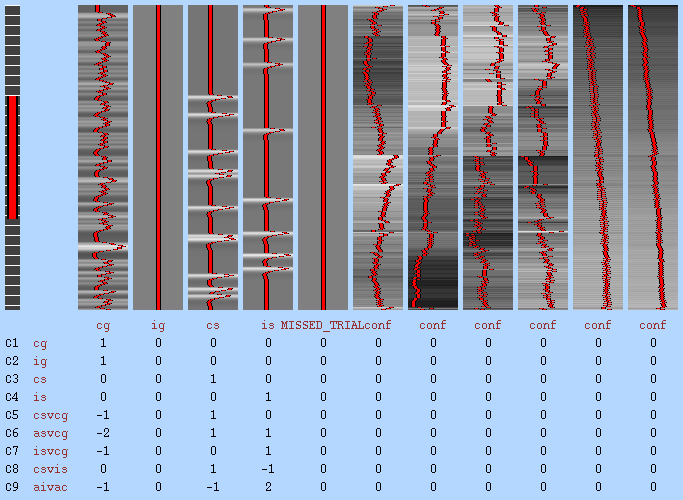

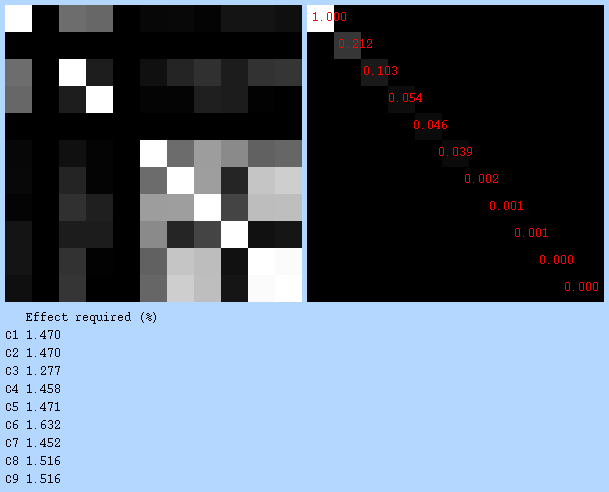

In [6]:
runtime_feat_output = runtime_feat_dir / 'feat' / f'{SUBJECT}_task-{TASK}_run-{RUN}_model-1b_demo'
runtime_feat_dir.joinpath('feat').mkdir(parents=True, exist_ok=True)
runtime_fsf_path = runtime_feat_dir / 'feat' / f'{SUBJECT}_task-{TASK}_run-{RUN}_model-1b_demo.fsf'
runtime_feat_output_dir = Path(str(runtime_feat_output) + '.feat')

feat_demo_files = {
    'fsf': FEAT_DEMO_DIR / f'{SUBJECT}_task-{TASK}_run-{RUN}_model-1b_demo.fsf',
    'design': FEAT_DEMO_DIR / 'design.png',
    'design_cov': FEAT_DEMO_DIR / 'design_cov.png',
    'example_func': FEAT_DEMO_DIR / 'example_func.nii.gz',
    'zstat1': FEAT_DEMO_DIR / 'zstat1.nii.gz',
    'report': FEAT_DEMO_DIR / 'report.html',
    'report_log': FEAT_DEMO_DIR / 'report_log.html',
    'feat1_log': FEAT_DEMO_DIR / 'feat1.log',
}

if not feat_demo_files['zstat1'].exists():
    template_text = (PROJECT_ROOT / 'templates' / 'L1_task-SST_model-1b_type-act.fsf').read_text()
    fsf_text = (
        template_text
        .replace('OUTPUT', str(runtime_feat_output))
        .replace('DATA', str(mcflirt_base.with_suffix('.nii.gz')))
        .replace('EVDIR', str((RUNTIME_PROJECT / 'derivatives' / 'fsl' / 'EVfiles' / SUBJECT / TASK / 'run-1')))
        .replace('SMOOTH', '5')
        .replace('NVOLS', str(bold_img.shape[3]))
        .replace('CONFOUNDEVS', str(mcflirt_par))
        .replace('EV_SHAPE', '10')
    )
    runtime_fsf_path.write_text(fsf_text)
    feat_ready, feat_load_method = load_fsl_module_if_needed()
    feat_cmd = find_first_command(['feat'])
    if feat_load_method and feat_load_method != 'already-on-path':
        print(f'FSL load method for FEAT cell: {feat_load_method}')
    if feat_cmd is None:
        raise FileNotFoundError(
            'Could not find feat on PATH, and automatic `ml fsl` / `module load fsl` did not succeed. '
            'Launch the notebook from a Neurodesk environment with FSL available.'
        )
    run([feat_cmd, str(runtime_fsf_path)], cwd=runtime_feat_dir)

    shutil.copy2(runtime_fsf_path, feat_demo_files['fsf'])
    shutil.copy2(runtime_feat_output_dir / 'design.png', feat_demo_files['design'])
    shutil.copy2(runtime_feat_output_dir / 'design_cov.png', feat_demo_files['design_cov'])
    shutil.copy2(runtime_feat_output_dir / 'example_func.nii.gz', feat_demo_files['example_func'])
    shutil.copy2(runtime_feat_output_dir / 'stats' / 'zstat1.nii.gz', feat_demo_files['zstat1'])
    shutil.copy2(runtime_feat_output_dir / 'report.html', feat_demo_files['report'])
    shutil.copy2(runtime_feat_output_dir / 'report_log.html', feat_demo_files['report_log'])
    shutil.copy2(runtime_feat_output_dir / 'logs' / 'feat1', feat_demo_files['feat1_log'])
    feat_mode = 'ran-feat-now'
else:
    feat_mode = 'reused-cached-feat-demo'

print(f'FEAT mode: {feat_mode}')
print(f'FSF file: {feat_demo_files["fsf"]}')
print(f'Example func: {feat_demo_files["example_func"]}')
print(f'zstat1: {feat_demo_files["zstat1"]}')

display(Image(filename=str(feat_demo_files['design'])))
display(Image(filename=str(feat_demo_files['design_cov'])))

assert feat_demo_files['design'].exists()
assert feat_demo_files['example_func'].exists()
assert feat_demo_files['zstat1'].exists()


## Step 6 - Visualize the FEAT result with Neurodesk MRIcroGL and embed the capture

Purpose:
- The assignment asks for visible output, so this section uses the Neurodesk `mricrogl` command-line tool to render the FEAT example function and `zstat1` map, save a PNG, and display that PNG inline.
- We avoid any hard-coded `/Applications/...` app bundle path so teammates can run the notebook independently in Neurodesk.

What the code is doing:
- Find the peak absolute voxel in `zstat1`.
- Convert that voxel index to millimeter coordinates.
- Write a small MRIcroGL Python script that loads the FEAT base image and overlay, sets threshold and opacity, centers the view on the peak activation, and saves a bitmap.
- Run `mricrogl` from the shell if it exists on `PATH`.
- If `mricrogl` is not available in the current environment, print a clear skip message instead of failing on a missing local app install.

QC checkpoint:
- In Neurodesk, the saved MRIcroGL PNG should show both the base image and the `zstat1` overlay.
- The screenshot path should be printed and the PNG should display inline below the cell.


In [7]:
zstat_img = nib.load(str(feat_demo_files['zstat1']))
zstat_data = zstat_img.get_fdata()
peak_idx = np.unravel_index(np.nanargmax(np.abs(zstat_data)), zstat_data.shape)
peak_mm = nib.affines.apply_affine(zstat_img.affine, peak_idx)

mricrogl_png = FEAT_FIG_DIR / f'{SUBJECT}_task-{TASK}_run-{RUN}_zstat1_mricrogl.png'
runtime_example_func = RUNTIME_PROJECT / 'output' / 'jupyter-notebook' / 'feat-demo' / 'example_func.nii.gz'
runtime_zstat1 = RUNTIME_PROJECT / 'output' / 'jupyter-notebook' / 'feat-demo' / 'zstat1.nii.gz'
mricrogl_rendered = False

mricrogl_script = textwrap.dedent(f'''    import gl
    gl.resetdefaults()
    gl.loadimage({str(runtime_example_func)!r})
    gl.overlayload({str(runtime_zstat1)!r})
    gl.minmax(1, 2.5, 8)
    gl.opacity(1, 80)
    gl.colorname(1, '1red')
    gl.orthoviewmm({peak_mm[0]:.3f}, {peak_mm[1]:.3f}, {peak_mm[2]:.3f})
    gl.savebmp({str(mricrogl_png)!r})
    gl.quit()
''').strip() + '\n'

print(f'Peak voxel index: {peak_idx}')
print(f'Peak millimeter coordinates: {tuple(round(v, 3) for v in peak_mm)}')

if MGL_CMD is None:
    print('SKIP: MRIcroGL command not found on PATH in this environment. This step is expected to run in Neurodesk where mricrogl is available.')
    if MCRON_CMD:
        print(f'MRIcron is available at: {MCRON_CMD}')
else:
    rendered_path, rendered_with, optional_mricron = render_with_mricrogl(mricrogl_script, mricrogl_png)
    mricrogl_rendered = True
    print(f'Rendered with: {rendered_with}')
    if optional_mricron:
        print(f'MRIcron also available at: {optional_mricron}')
    print(f'MRIcroGL screenshot: {rendered_path}')
    display(Image(filename=str(rendered_path)))


Peak voxel index: (41, 20, 20)
Peak millimeter coordinates: (-2.7, -51.3, -27.175)
SKIP: MRIcroGL command not found on PATH in this environment. This step is expected to run in Neurodesk where mricrogl is available.


## Troubleshooting and summary

Common issues:
- If `datalad` and `git-annex` are missing, the notebook will fall back to direct OpenNeuro downloads. The printed DataLad commands are still the right commands to use in a fully configured Neurodesk-style environment.
- In Neurodesk, the notebook should prefer a project-local runtime under `output/jupyter-notebook/_runtime/`. The `/tmp` runtime fallback is only for local clones whose project path contains spaces.
- If the FEAT cell is slow, rerun the notebook once the demo outputs already exist. The notebook will then reuse the cached FEAT products.
- The all-subject EV step is designed to be lightweight: with `--skip-feat`, the shared runner downloads only `events.tsv` files instead of the full BOLD inputs.
- For visualization, the notebook now expects `mricrogl` or `MRIcroGL` on `PATH`. That matches Neurodesk more closely than a hard-coded local app bundle.

Suggested extension:
- Repeat the FEAT section for SST run 2 or swap the MRIcroGL color map and capture a second screenshot for comparison.


In [8]:
summary_rows = [
    {'artifact': 'Representative T1w PNG', 'path': str(FIG_DIR / f'{SUBJECT}_T1w.png')},
    {'artifact': 'Representative BOLD PNG', 'path': str(FIG_DIR / f'{SUBJECT}_task-{TASK}_run-{RUN}_middle-volume.png')},
    {'artifact': 'MCFLIRT confounds TSV', 'path': str(CONF_DIR / f'{SUBJECT}_task-{TASK}_run-{RUN}_mcflirt_confounds.tsv')},
    {'artifact': 'FD QC plot', 'path': str(CONF_DIR / f'{SUBJECT}_task-{TASK}_run-{RUN}_fd-plot.png')},
    {'artifact': 'All-subject SST EV manifest', 'path': str(all_ev_manifest_path)},
    {'artifact': 'All-subject SST EV root', 'path': str(PROJECT_ROOT / 'derivatives' / 'fsl' / 'EVfiles')},
    {'artifact': 'FEAT FSF file', 'path': str(feat_demo_files['fsf'])},
    {'artifact': 'FEAT design matrix PNG', 'path': str(feat_demo_files['design'])},
    {'artifact': 'FEAT zstat1', 'path': str(feat_demo_files['zstat1'])},
]
if mricrogl_rendered:
    summary_rows.append({'artifact': 'MRIcroGL screenshot', 'path': str(mricrogl_png)})
else:
    summary_rows.append({'artifact': 'MRIcroGL screenshot', 'path': 'Not generated in this environment'})
summary = pd.DataFrame(summary_rows)
display(summary)


,artifact,path
0,Representative T1w PNG,/Users/kwakufinest/Documents/New project/group...
1,Representative BOLD PNG,/Users/kwakufinest/Documents/New project/group...
2,MCFLIRT confounds TSV,/Users/kwakufinest/Documents/New project/group...
3,FD QC plot,/Users/kwakufinest/Documents/New project/group...
4,All-subject SST EV manifest,/Users/kwakufinest/Documents/New project/group...
5,All-subject SST EV root,/Users/kwakufinest/Documents/New project/group...
6,FEAT FSF file,/Users/kwakufinest/Documents/New project/group...
7,FEAT design matrix PNG,/Users/kwakufinest/Documents/New project/group...
8,FEAT zstat1,/Users/kwakufinest/Documents/New project/group...
9,MRIcroGL screenshot,Not generated in this environment
